### 1. Configuración y Carga de Funciones
Definimos los parámetros de análisis y las funciones para extraer características temporales y espectrales basadas en tu código.

In [16]:
import torch
import torchaudio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.stats import skew, kurtosis
from pathlib import Path

###Archivos

In [17]:
path_normal = "2026-08-14_10-14-58.wav"
path_4k = "2026-08-18_13-24-50_4k.wav"

In [18]:
TARGET_SR = 32000
N_FFT = 1024
HOP_LENGTH = 256
N_MELS = 128
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [19]:
def load_audio(path):
    waveform, sr = torchaudio.load(str(path))
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)
    return waveform, sr

def amplitude_temporal_features(x_np):
    """Features de amplitud + temporales completas según el prompt."""
    abs_x = np.abs(x_np)
    rms = float(np.sqrt(np.mean(x_np ** 2)))
    peak = float(np.max(abs_x))
    mean_abs = float(np.mean(abs_x))
    std = float(np.std(x_np))
    crest_factor = peak / (rms + 1e-12)
    zcr = float(np.mean(np.diff(np.signbit(x_np)) != 0))
    energy = float(np.mean(x_np ** 2))
    skewness = float(skew(x_np))
    kurt = float(kurtosis(x_np))
    p01, p99 = np.percentile(abs_x, [1, 99])
    dynamic_range = float(p99 / (p01 + 1e-12))

    return {
        "rms": rms, "peak": peak, "mean_abs": mean_abs, "std": std,
        "crest_factor": crest_factor, "zcr": zcr, "energy": energy,
        "skewness": skewness, "kurtosis": kurt, "dynamic_range": dynamic_range,
    }

def spectral_features(x_tensor, sr):
    """Features espectrales completas."""
    spec = torch.stft(x_tensor, n_fft=N_FFT, hop_length=HOP_LENGTH, win_length=N_FFT, return_complex=True)
    magnitude = spec.abs()
    freqs = torch.fft.rfftfreq(N_FFT, d=1 / sr).to(magnitude.device)
    spectrum = magnitude.mean(dim=1)
    eps = 1e-12
    total = spectrum.sum() + eps

    centroid = (freqs * spectrum).sum() / total
    bandwidth = torch.sqrt(((freqs - centroid) ** 2 * spectrum).sum() / total)
    cumulative = torch.cumsum(spectrum, dim=0)
    rolloff_idx = min(torch.searchsorted(cumulative, 0.85 * total).item(), len(freqs) - 1)
    rolloff = freqs[rolloff_idx]
    dominant_idx = torch.argmax(spectrum)
    dominant_freq = freqs[dominant_idx]

    return {
        "spectral_centroid": centroid.item(),
        "spectral_bandwidth": bandwidth.item(),
        "spectral_rolloff": rolloff.item(),
        "dominant_frequency": dominant_freq.item(),
    }

### 2. Extracción de Características y Análisis Comparativo
Calculamos las métricas para ambos archivos y comparamos sus valores de RMS (dB) y Centroide Espectral.

In [20]:
results = []
for p in [path_normal, path_4k]:
    if not Path(p).exists(): continue
    w, sr = load_audio(p)
    x_np = w.squeeze(0).numpy()

    # Extraer todas las características solicitadas
    feats = amplitude_temporal_features(x_np)
    feats.update(spectral_features(w.squeeze(0), sr))
    feats['filename'] = Path(p).name
    feats['rms_db'] = 20 * np.log10(max(feats['rms'], 1e-8))
    results.append(feats)

if results:
    df_comp = pd.DataFrame(results)
    # Mostrar todas las columnas técnicas solicitadas
    display(df_comp.transpose())
else:
    print("Error: No se pudieron procesar los archivos.")

,0,1
rms,0.024393,0.058459
peak,0.481171,0.5
mean_abs,0.007728,0.012543
std,0.024379,0.05791
crest_factor,19.725498,8.553028
zcr,0.03266,0.019384
energy,0.000595,0.003417
skewness,-3.986906,-6.943423
kurtosis,70.659996,53.080204
dynamic_range,4297.029859,15934.249478


### 3. Visualización de Espectrogramas de Mel
Comparamos visualmente cómo el filtro de 4kHz afecta las frecuencias altas del audio.

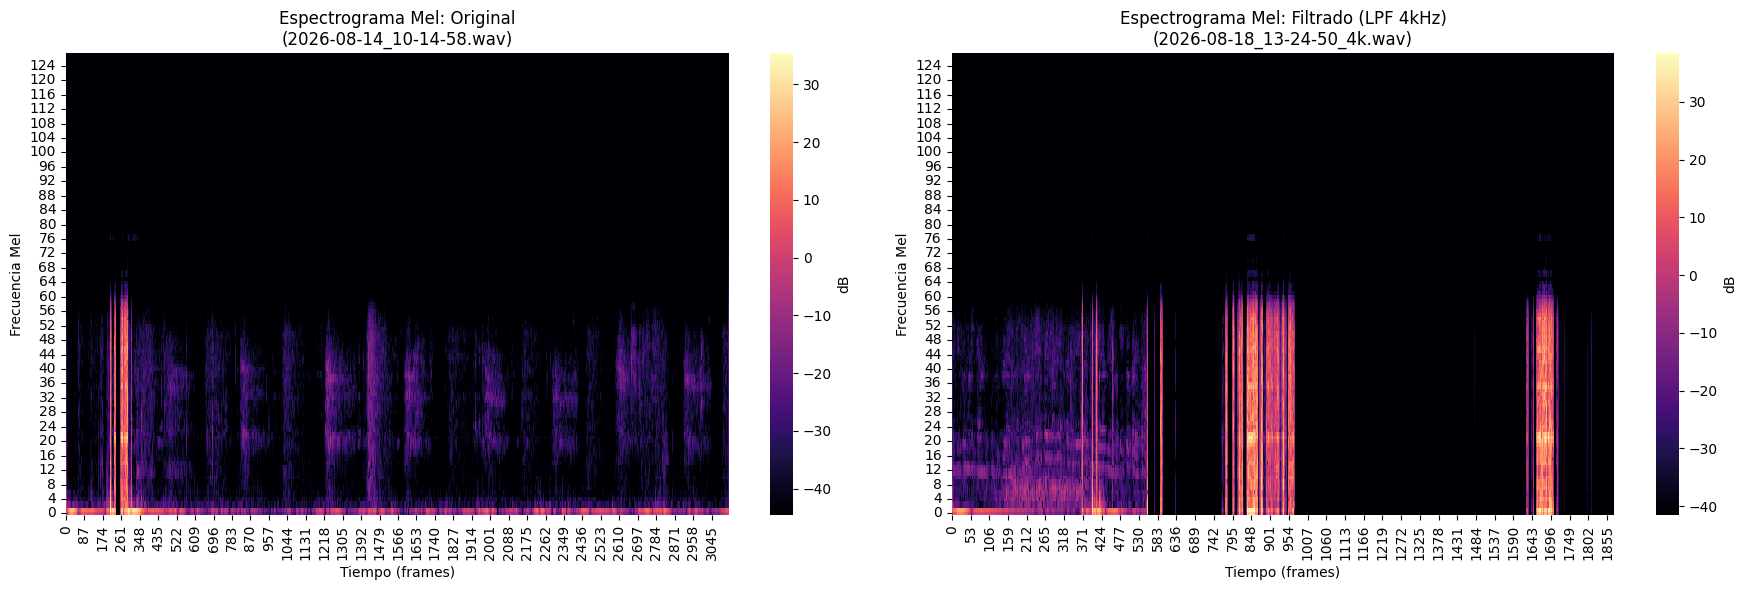

In [21]:
mel_transform = torchaudio.transforms.MelSpectrogram(sample_rate=TARGET_SR, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS)
db_transform = torchaudio.transforms.AmplitudeToDB(stype="power", top_db=80)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
for i, p in enumerate([path_normal, path_4k]):
    w, sr = load_audio(p)
    if sr != TARGET_SR: w = torchaudio.functional.resample(w, sr, TARGET_SR)
    mel_db = db_transform(mel_transform(w)).squeeze(0)

    title_type = "Original" if "4k" not in p else "Filtrado (LPF 4kHz)"
    sns.heatmap(mel_db.numpy(), cmap="magma", ax=axes[i], cbar_kws={"label": "dB"})
    axes[i].set_title(f"Espectrograma Mel: {title_type}\n({Path(p).name})", fontsize=12)
    axes[i].set_xlabel("Tiempo (frames)")
    axes[i].set_ylabel("Frecuencia Mel")
    axes[i].invert_yaxis()

plt.tight_layout()
plt.show()

### 4. Distribución y Correlación de Características
Visualizamos cómo se distribuyen las métricas entre los archivos y la correlación entre las diferentes variables acústicas extraídas.

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be remo

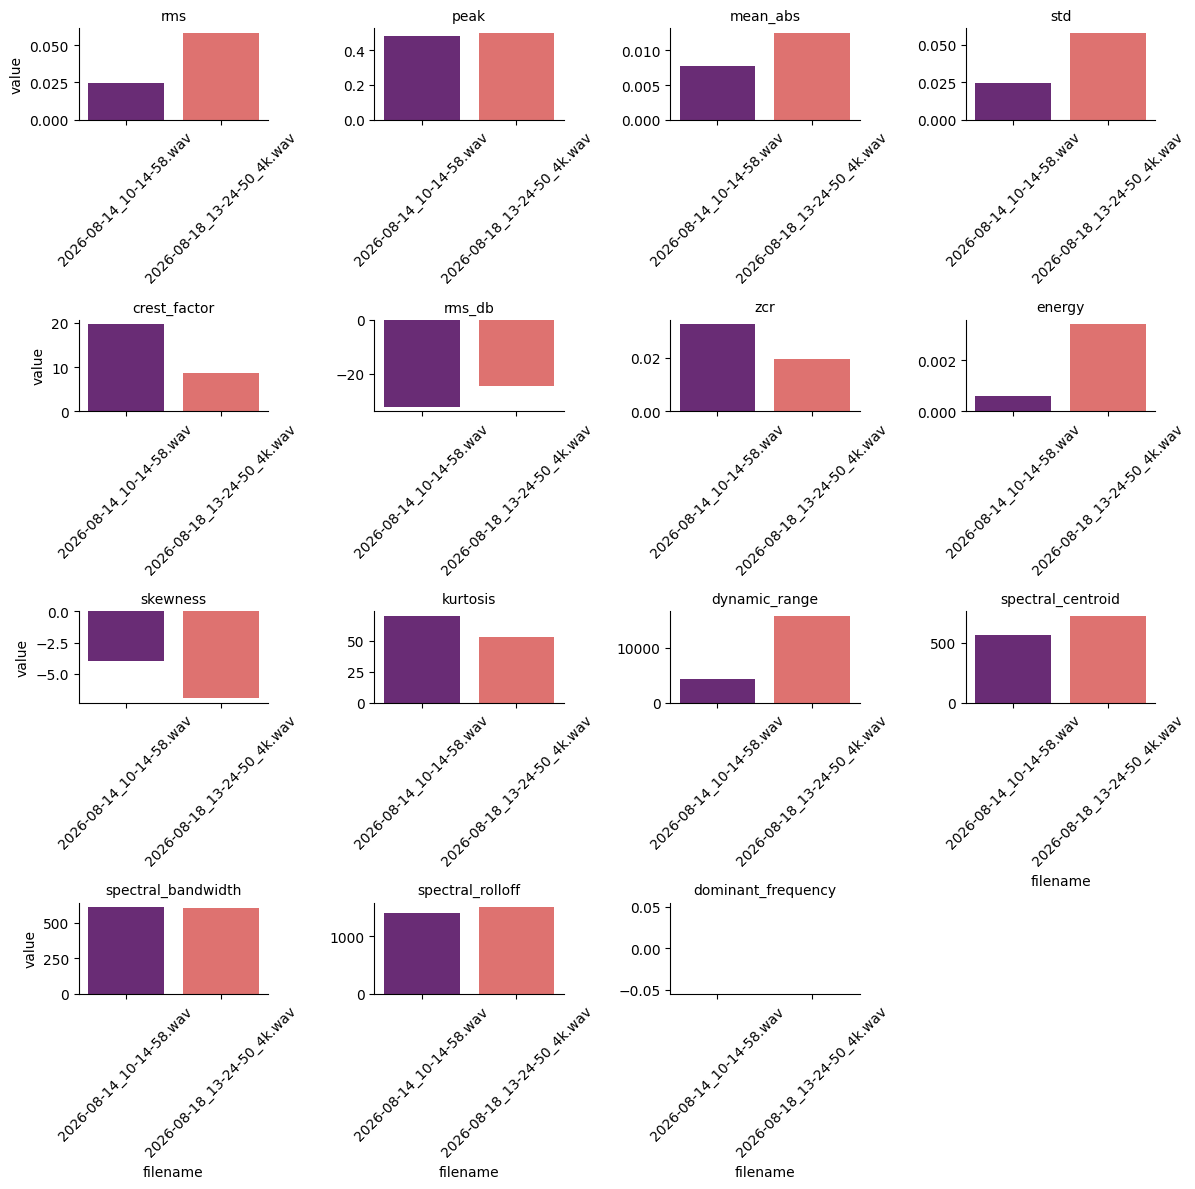

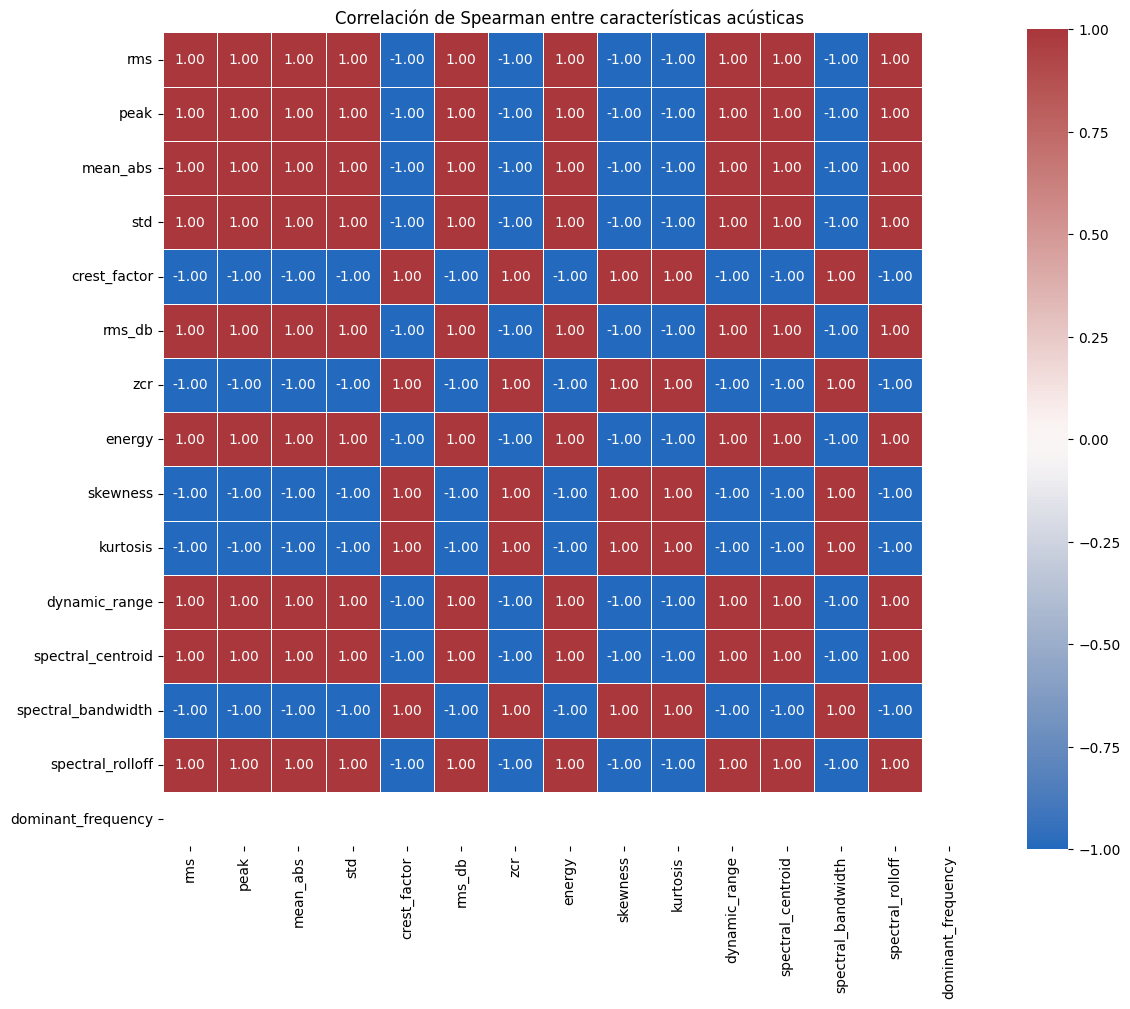

In [23]:
# Definir columnas de interés basadas en el código inicial
FEATURE_COLUMNS = [
    "rms", "peak", "mean_abs", "std", "crest_factor", "rms_db",
    "zcr", "energy", "skewness", "kurtosis", "dynamic_range",
    "spectral_centroid", "spectral_bandwidth", "spectral_rolloff", "dominant_frequency",
]

# Filtrar solo las columnas que existan en nuestro DataFrame de comparación
available_features = [c for c in FEATURE_COLUMNS if c in df_comp.columns]

# 1. Comparativa de distribución mediante gráficos de barras (al ser solo 2 archivos)
long_df = df_comp.melt(id_vars=['filename'], value_vars=available_features, var_name="feature", value_name="value")
g = sns.FacetGrid(long_df, col="feature", col_wrap=4, height=3, sharex=False, sharey=False)
g.map_dataframe(sns.barplot, x="filename", y="value", palette="magma")
g.set_titles("{col_name}")
for ax in g.axes.flat:
    for label in ax.get_xticklabels():
        label.set_rotation(45)
plt.tight_layout()
plt.show()

# 2. Matriz de Correlación (Spearman)
if len(df_comp) > 1:
    corr = df_comp[available_features].corr(method="spearman")
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr, annot=True, cmap="vlag", center=0, fmt=".2f", square=True, linewidths=0.5)
    plt.title("Correlación de Spearman entre características acústicas")
    plt.tight_layout()
    plt.show()
else:
    print("Se requieren más archivos para calcular una matriz de correlación significativa.")

### 4. Distribución y Correlación de Características
Visualizamos cómo se distribuyen las métricas entre los archivos y la correlación entre las diferentes variables acústicas extraídas.

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be remo

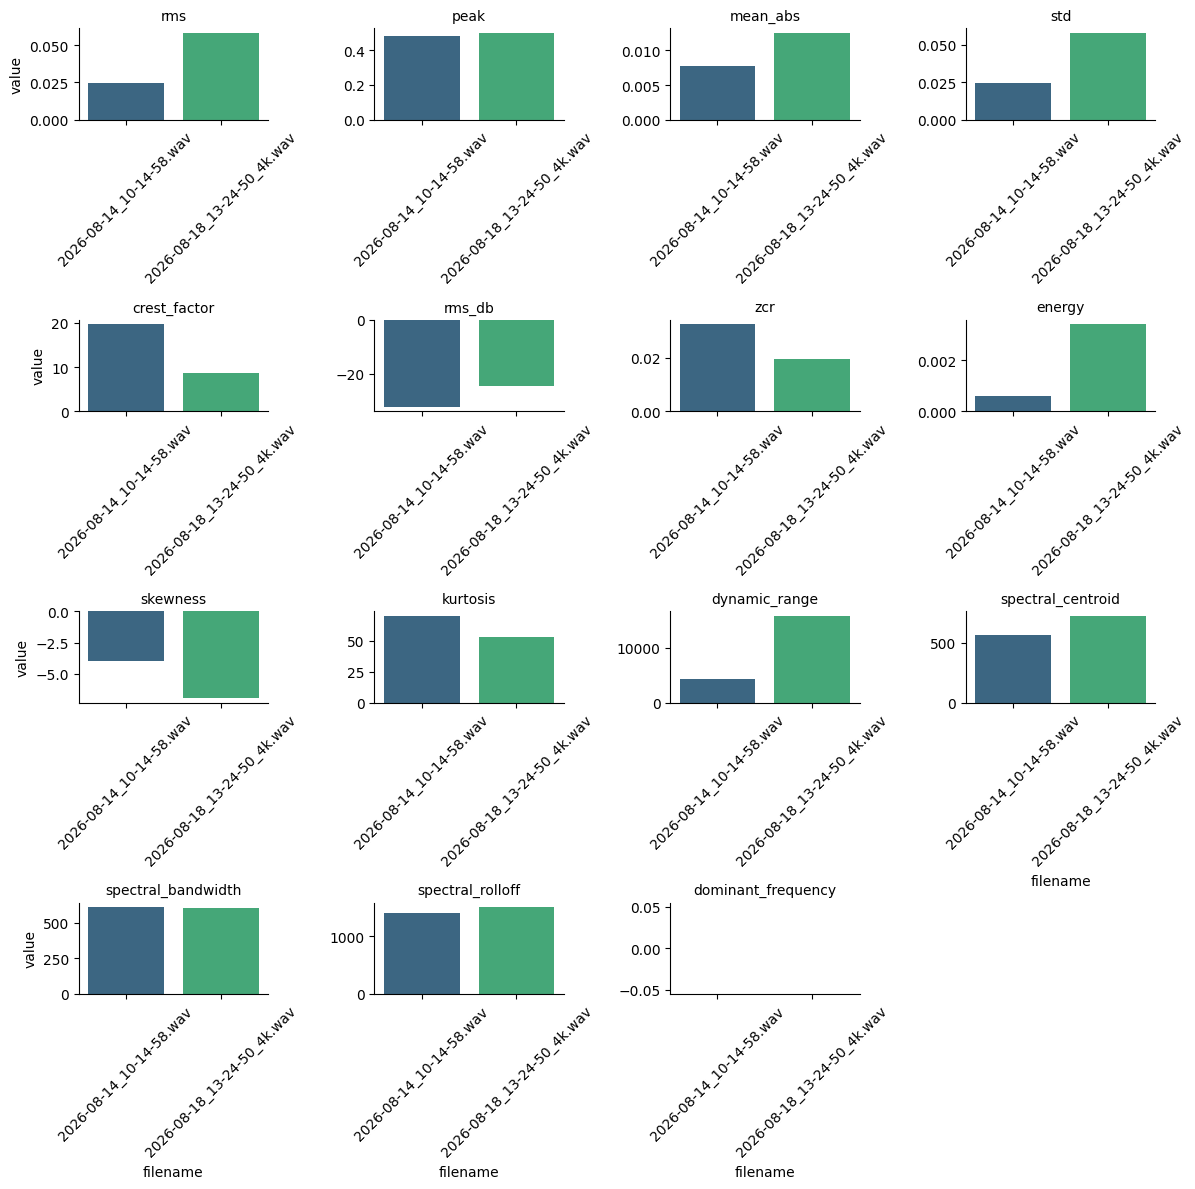

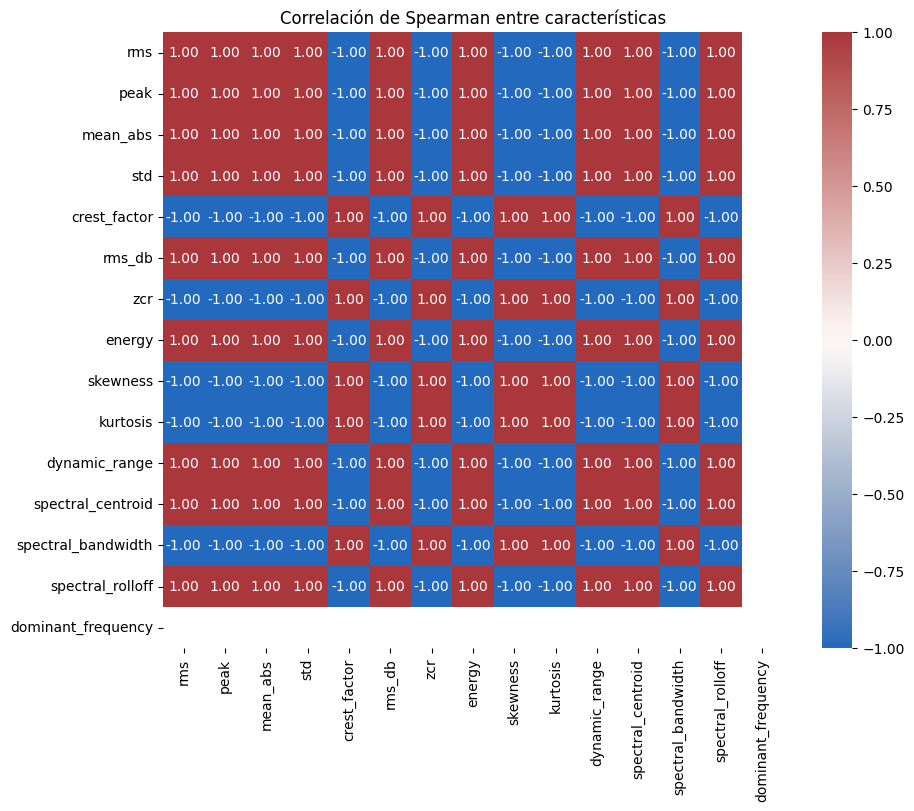

In [22]:
# Definir columnas de interés
FEATURE_COLUMNS = [
    "rms", "peak", "mean_abs", "std", "crest_factor", "rms_db",
    "zcr", "energy", "skewness", "kurtosis", "dynamic_range",
    "spectral_centroid", "spectral_bandwidth", "spectral_rolloff", "dominant_frequency",
]

# Filtrar solo las columnas que existan en nuestro DataFrame de comparación
available_features = [c for c in FEATURE_COLUMNS if c in df_comp.columns]

# 1. Histogramas de distribución
long_df = df_comp.melt(id_vars=['filename'], value_vars=available_features, var_name="feature", value_name="value")
g = sns.FacetGrid(long_df, col="feature", col_wrap=4, height=3, sharex=False, sharey=False)
g.map_dataframe(sns.barplot, x="filename", y="value", palette="viridis")
g.set_titles("{col_name}")
g.set_xticklabels(rotation=45)
plt.tight_layout()
plt.show()

# 2. Matriz de Correlación (Spearman)
if len(df_comp) > 1:
    corr = df_comp[available_features].corr(method="spearman")
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, cmap="vlag", center=0, fmt=".2f")
    plt.title("Correlación de Spearman entre características")
    plt.show()
else:
    print("Se requieren al menos 2 archivos para calcular correlaciones.")